# Ejercicio 8 - Analisis con 2024, 2025 y 2026

Con 2025 incorporado (`python scripts/download_data.py` descarga 2024-2026), las consultas de los ejercicios
anteriores se ejecutan sin cambios (`docs/resultados/*_2024_2025_2026.md`). Este notebook analiza la **evolucion**
de los indicadores entre los tres anios con las consultas de `sql/08_evolucion/`.

> Nota de recursos: las consultas con cuantiles exactos sobre ~120 M de filas necesitan ~4-5 GB de RAM. Si la VM de
> Docker tiene 8 GB, detener Metabase mientras se ejecuta este notebook (`docker compose stop metabase`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
from lab_db import DIR_SQL, connect, leer_consulta, run_query_file

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = connect()   # conexion en memoria + vistas de sql/00_views.sql sobre los Parquet

In [2]:
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}   # paleta categorica validada (slots 1-3)

## 8.5 Resumen anual con periodo comparable (enero-agosto)

### `01_resumen_anual.sql`

- **Pregunta:** Como cambiaron los indicadores principales entre 2024, 2025 y 2026 en el mismo periodo del anio?
- **Objetivo:** Comparacion anual con periodo comparable (enero-agosto, los meses disponibles de 2026).
- **Fuente:** vista trips_clean.

In [3]:
df, seg = run_query_file(con, DIR_SQL / "08_evolucion" / "01_resumen_anual.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

5.61 s, 6 filas


,anio,taxi_type,viajes_ene_ago,ticket_mediano_usd,distancia_mediana_mi,pct_efectivo_informados,pct_pago_sin_dato,propina_mediana_pct,cargo_cbd_promedio_usd
0,2024,green,412475,19.15,1.98,28.85,4.07,23.49,0.000
1,2025,green,368823,19.85,2.04,24.75,6.46,23.49,0.074
2,2026,green,314462,20.50,2.14,22.65,13.56,23.64,0.064
3,2024,yellow,25416332,21.00,1.80,15.09,9.01,25.93,0.000
4,2025,yellow,28595784,21.61,1.88,12.38,19.65,26.69,0.548
5,2026,yellow,28134580,23.58,1.94,11.99,24.99,26.41,0.544


## Variacion interanual de la demanda

### `02_variacion_interanual.sql`

- **Pregunta:** Cuanto crecio o cayo la demanda de cada mes respecto al mismo mes del anio anterior?
- **Objetivo:** Variacion interanual (YoY) de viajes por mes y tipo usando lag() sobre el anio.
- **Fuente:** vista trips_clean.

In [4]:
df, seg = run_query_file(con, DIR_SQL / "08_evolucion" / "02_variacion_interanual.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

1.00 s, 64 filas


,taxi_type,mes,anio,viajes,var_pct_vs_anio_anterior
0,green,1,2024,52735,NaN
1,green,1,2025,44756,-15.1
2,green,1,2026,37755,-15.6
3,green,2,2024,49908,NaN
4,green,2,2025,42954,-13.9
...,...,...,...,...,...
59,yellow,10,2025,3929408,7.1
60,yellow,11,2024,3496967,NaN
61,yellow,11,2025,3630080,3.8
62,yellow,12,2024,3505036,NaN


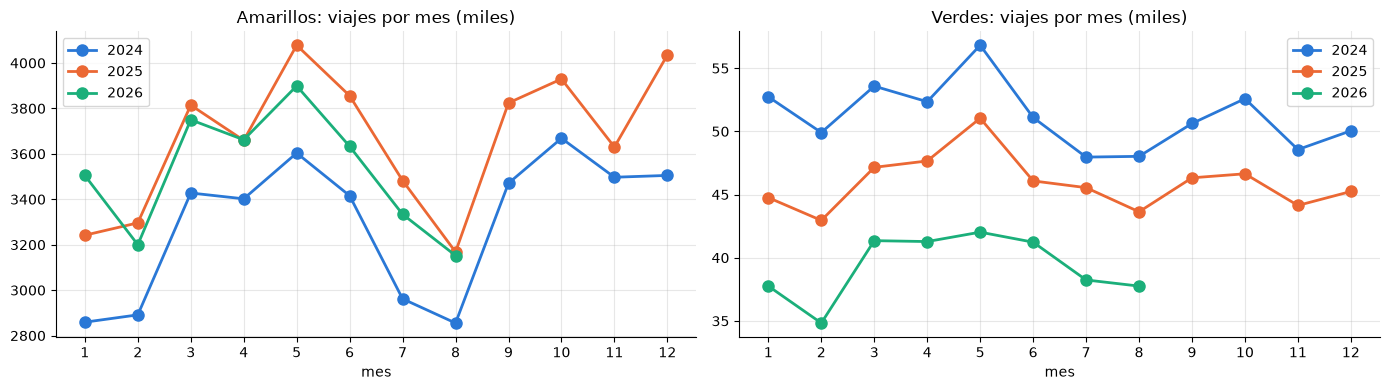

In [5]:
df = run_query_file(con, DIR_SQL / "08_evolucion" / "02_variacion_interanual.sql")[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, t, titulo in zip(axes, ["yellow", "green"], ["Amarillos", "Verdes"]):
    for anio, g in df[df.taxi_type == t].groupby("anio"):
        ax.plot(g.mes, g.viajes / 1e3, marker="o", ms=8, lw=2, color=COLOR_ANIO[anio], label=str(anio))
    ax.set_title(f"{titulo}: viajes por mes (miles)"); ax.set_xlabel("mes"); ax.set_xticks(range(1, 13)); ax.legend()
plt.tight_layout(); plt.show()

## Peaje de congestion (desde enero 2025) y velocidad dentro de Manhattan

### `03_velocidad_manhattan.sql`

- **Pregunta:** Cambio la velocidad de los viajes dentro de Manhattan con el peaje de congestion (vigente desde enero de 2025)?
- **Objetivo:** Velocidad mediana de taxis amarillos con origen y destino en Manhattan, lunes a viernes de 7 a 19 h, por mes.
- **Fuente:** vista trips_clean + vista zones.

In [6]:
df, seg = run_query_file(con, DIR_SQL / "08_evolucion" / "03_velocidad_manhattan.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

1.76 s, 32 filas


,mes,viajes,velocidad_mediana_mph,duracion_mediana_min,pct_con_cargo_cbd
0,2024-01-01,1354660,8.23,11.0,NaN
1,2024-02-01,1333600,7.96,11.4,NaN
2,2024-03-01,1434057,7.95,11.8,NaN
3,2024-04-01,1515350,7.80,12.1,NaN
4,2024-05-01,1641092,7.43,12.7,NaN
5,2024-06-01,1423522,7.68,12.2,NaN
6,2024-07-01,1375162,8.00,11.8,NaN
7,2024-08-01,1247368,8.07,11.6,NaN
8,2024-09-01,1432461,7.25,13.0,NaN
9,2024-10-01,1630392,7.18,12.9,NaN


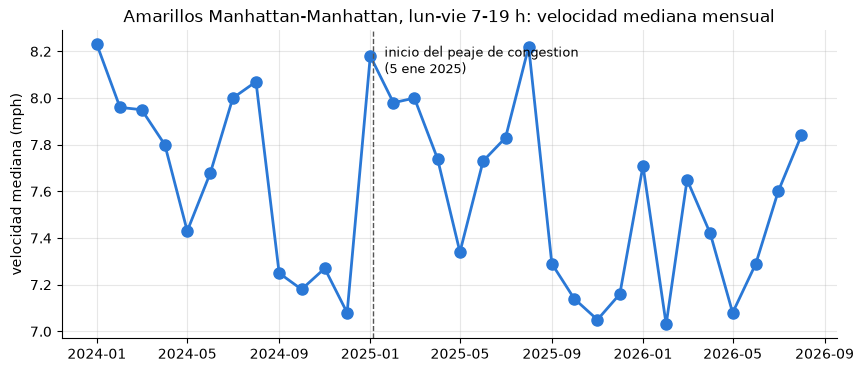

In [7]:
df = run_query_file(con, DIR_SQL / "08_evolucion" / "03_velocidad_manhattan.sql")[0]
df["mes"] = pd.to_datetime(df.mes)
fig, ax = plt.subplots()
ax.plot(df.mes, df.velocidad_mediana_mph, marker="o", ms=8, lw=2, color="#2a78d6")
ax.axvline(pd.Timestamp("2025-01-05"), color="#555", ls="--", lw=1)
ax.annotate("inicio del peaje de congestion\n(5 ene 2025)", (pd.Timestamp("2025-01-05"), df.velocidad_mediana_mph.max()),
            xytext=(8, 0), textcoords="offset points", fontsize=9, va="top")
ax.set_ylabel("velocidad mediana (mph)")
ax.set_title("Amarillos Manhattan-Manhattan, lun-vie 7-19 h: velocidad mediana mensual"); plt.show()

## Calidad del dato de pago por proveedor

### `04_canales_y_proveedores.sql`

- **Pregunta:** Cambio la composicion de proveedores (VendorID) de los taxis a lo largo de los tres anios?
- **Objetivo:** Participacion de cada VendorID por anio y tipo; ayuda a explicar cambios en la calidad del dato (pago sin informar).
- **Fuente:** vista trips (sin limpiar, para no ocultar registros incompletos).

In [8]:
df, seg = run_query_file(con, DIR_SQL / "08_evolucion" / "04_canales_y_proveedores.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.24 s, 20 filas


,anio,taxi_type,vendor_id,viajes,pct_del_anio,pct_pago_sin_dato
0,2024,green,1,80450,12.19,1.4
1,2024,green,2,579768,87.81,4.0
2,2025,green,1,65489,11.07,1.5
3,2025,green,2,498801,84.35,4.4
4,2025,green,6,27085,4.58,100.0
5,2026,green,1,28696,8.51,1.8
6,2026,green,2,273571,81.15,4.9
7,2026,green,6,34847,10.34,100.0
8,2024,yellow,1,9715918,23.60,8.9
9,2024,yellow,2,31451503,76.39,10.3


## Indicadores del tablero con los tres anios

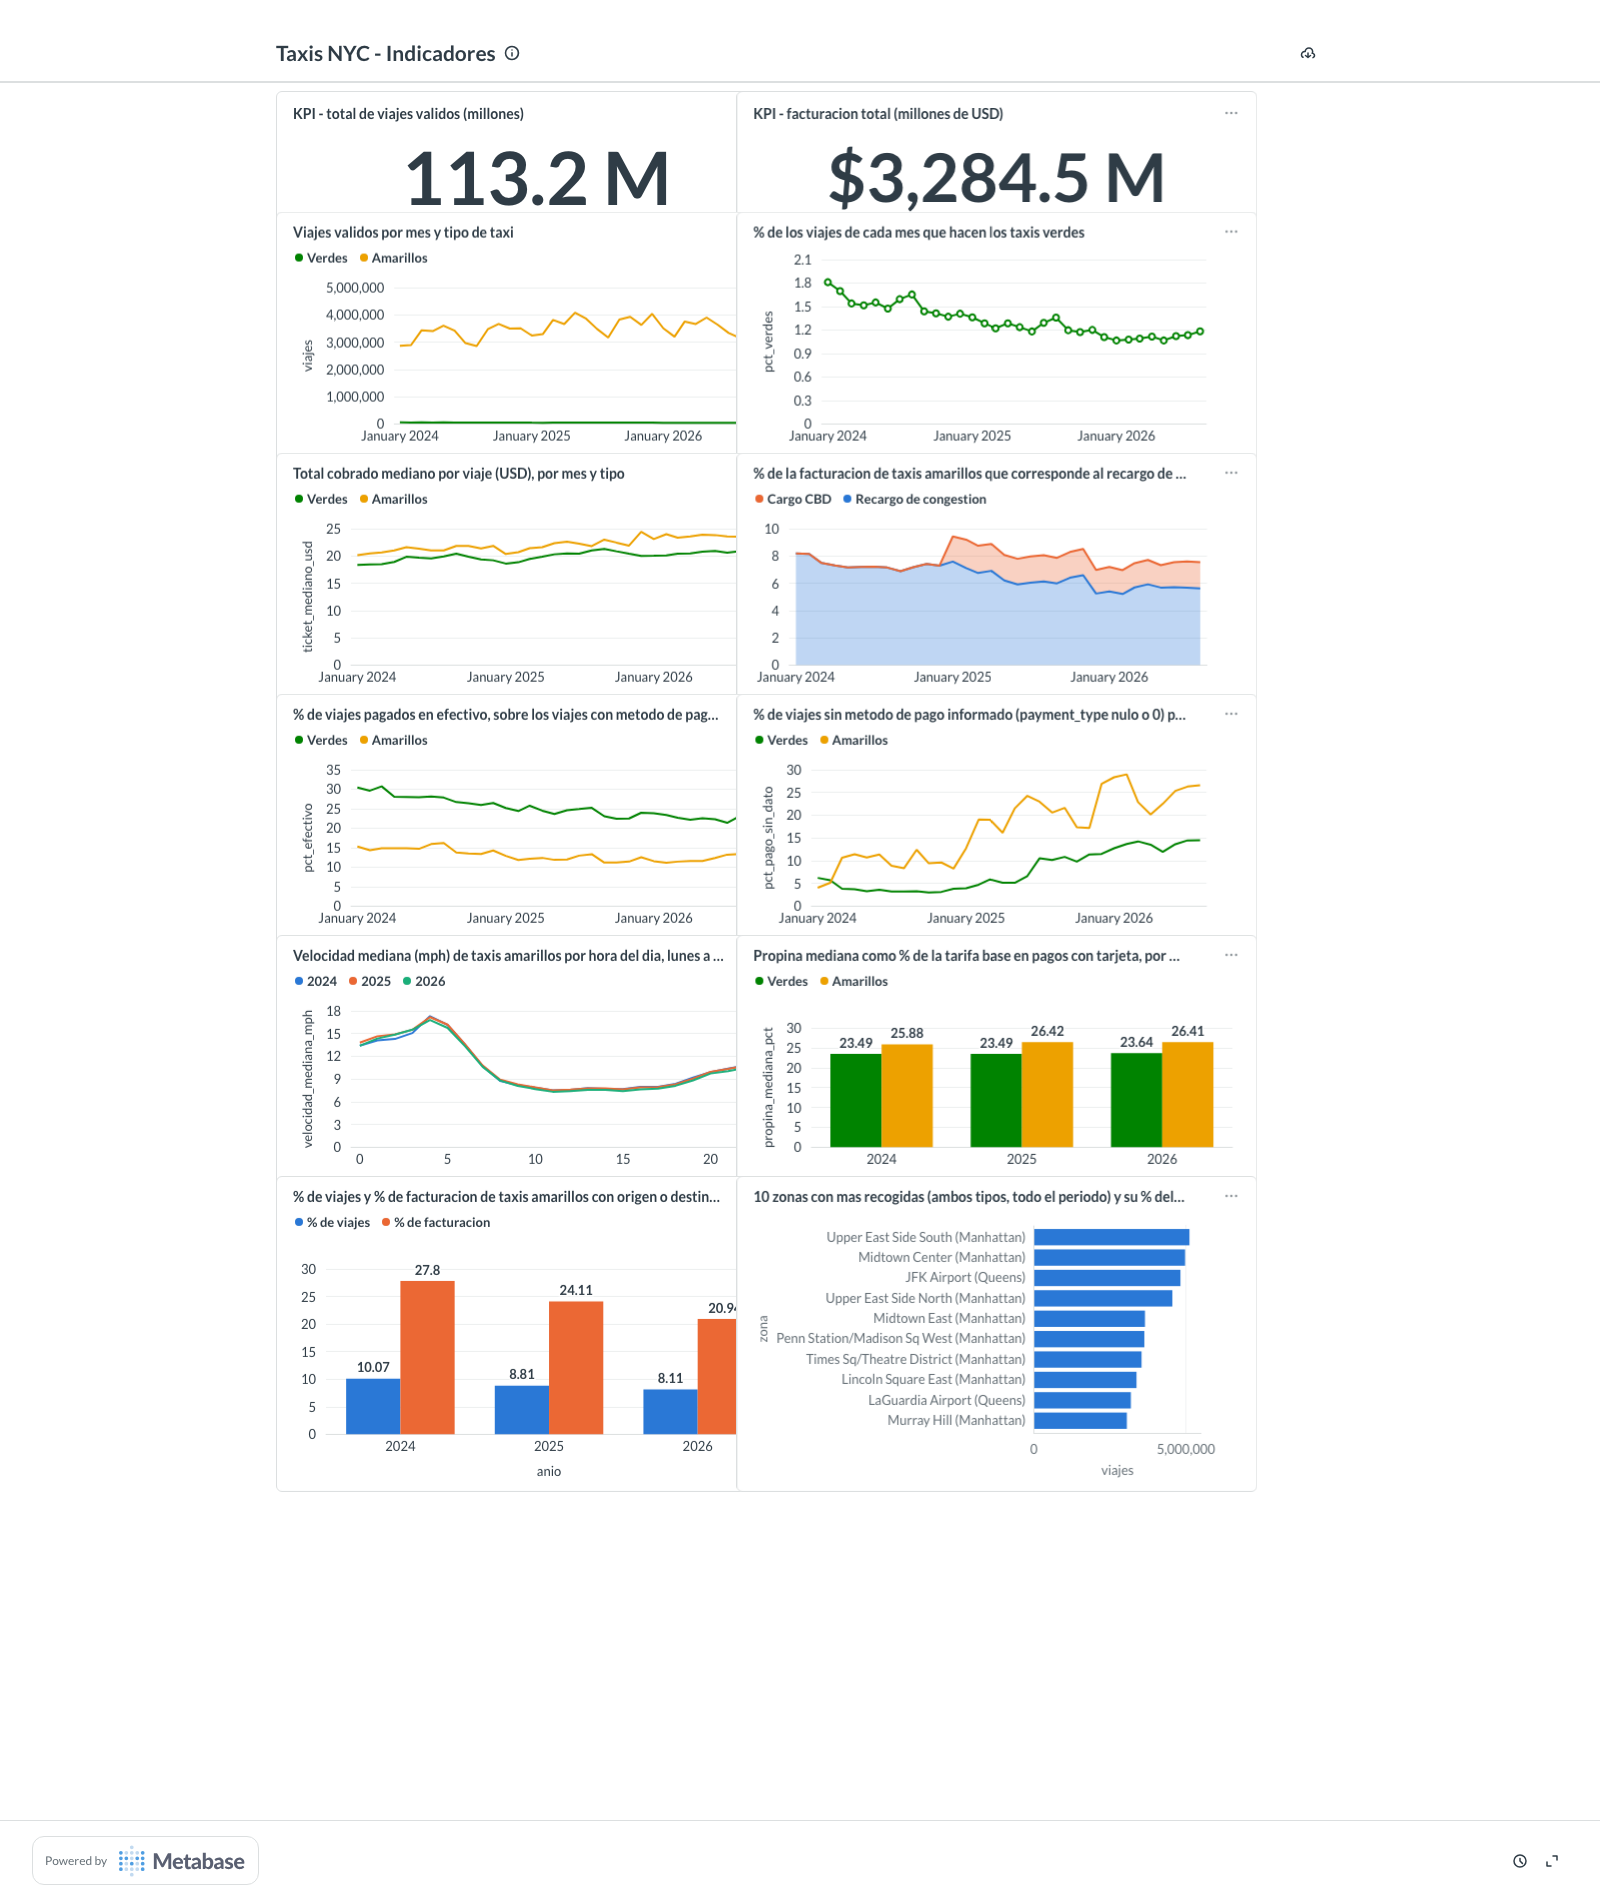

In [9]:
from lab_db import RAIZ
from IPython.display import Image
Image(filename=str(RAIZ / "docs/dashboard/tablero_2024_2025_2026.png"), width=900)